# Correct pressure offset between pressure sensors

First we need to 0 nav pressure. Find min pressure read m_pressure every 3 dives (which is when we are at surface)

Shift m_nav so surface is 0

Get bias at top and bottom of the dive between m_pressure and sci_pressure - shift science pressure so reads the same as m_pressure

There are two pressure sensors: m_pressure is the glider pressure sensor, sci_water_pressure is the science pressure sensor

In [59]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gsw

In [ ]:
ds=xr.open_dataset('L0-timeseries/wam_sbus_1230.nc')#.sel(time=slice('2026-01-25', '2026-03-30'))
ds=ds.where(ds.time>pd.to_datetime('2025-01-01'), drop=True)
ds['m_pressure']=ds.m_pressure*10
ds = ds.isel(time=~ds.indexes['time'].duplicated())

In [ ]:
# Interpolate pressure and profile index

In [63]:
ds['pressure']=ds.pressure.interpolate_na(dim='time')
ds['m_pressure']=ds.m_pressure.interpolate_na(dim='time')

    # also seems like profile index needs interpolating, use ffill (TODO:see if this is an issue)
ds.profile_index[ds.profile_index==0]=np.nan
ds['profile_index']=ds.profile_index.ffill(dim='time')
ds['profile_index']=ds['profile_index'].bfill('time')

In [ ]:
# GET DIVE NUMBER

#group by timseries by profile index
prof_ds = ds.groupby('profile_index').mean()
prof_ind= prof_ds.profile_index

#get profile direction
profdir = ds.groupby('profile_index').sum().profile_direction
profile_direction = profdir/np.abs(profdir)

print(np.unique(profile_direction))

# dive number will be when diff between prof direction is 2, (1 decending, -1 ascending, 1-(-1)=2)
# dive_number = (profile_direction.diff('profile_index') == 2) \
#                 .fillna(False) \
#                 .cumsum('profile_index') + 1
dive_number = (profile_direction.diff('profile_index') != -2) \
                .fillna(False) \
                .cumsum('profile_index') + 1

prof_ds['divenum']=dive_number

# nan dive numbers where prof direction adds up different to 0 (should be o, 1 + (-1) = 0)
# dir_sum = prof_ds.groupby('divenum').sum().profile_direction
# bad_ids = dir_sum['divenum'].where(dir_sum != 0, drop=True)
# prof_ds['divenum_qc'] = prof_ds['divenum'].where(~prof_ds['divenum'].isin(bad_ids))

prof_ds['profile_direction_mean']=profile_direction
dir_sum=prof_ds['profile_direction_mean'].groupby(prof_ds.divenum).sum()
# dir_sum = prof_ds.groupby('divenum').sum().profile_direction
bad_ids = dir_sum['divenum'].where(dir_sum == 1, drop=True)
prof_ds['divenum_qc'] = prof_ds['divenum'].where(~prof_ds['divenum'].isin(bad_ids))

## back to timeseries
dive_num=xr.DataArray(prof_ds.divenum_qc.sel(profile_index=ds.profile_index).ffill(dim='time').fillna(0.0).values,dims='time')
ds['dive_index']=dive_num

/opt/miniconda3/envs/gliderwork/lib/python3.11/site-packages/xarray/structure/concat.py:637: UserWarning: No index created for dimension profile_index because variable profile_index is not a coordinate. To create an index for profile_index, please first call `.set_coords('profile_index')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/opt/miniconda3/envs/gliderwork/lib/python3.11/site-packages/xarray/structure/concat.py:637: UserWarning: No index created for dimension profile_index because variable profile_index is not a coordinate. To create an index for profile_index, please first call `.set_coords('profile_index')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


[-1.  1.]


In [ ]:
# Correct m_pressure (navigation pressure) 
# Get min per profile and make it 0! Rolling a min every 12 profiles, because 3 multidives, so min is when glider is at surface

In [ ]:
mbias_=(ds.m_pressure.groupby(ds.profile_index).min())
mbias_=mbias_.rolling(profile_index=12,center=True).min().bfill('profile_index') #12 to filter over multiyos
mbias_dpth=xr.DataArray(mbias_.sel(profile_index=ds.profile_index).ffill(dim='time').fillna(0.0).values,dims='time')

ds['m_pressure_corr']=ds['m_pressure']-mbias_dpth

In [ ]:
# using dive variable (NOT USED)
# mbias_=(ds.m_pressure.groupby(ds.dive_index).min())
# mbias_=mbias_.rolling(dive_index=6,center=True).min() #12 to filter over multiyos
# mbias_dpth=xr.DataArray(mbias_.sel(dive_index=ds.dive_index).ffill(dim='time').fillna(0.0).values,dims='time')

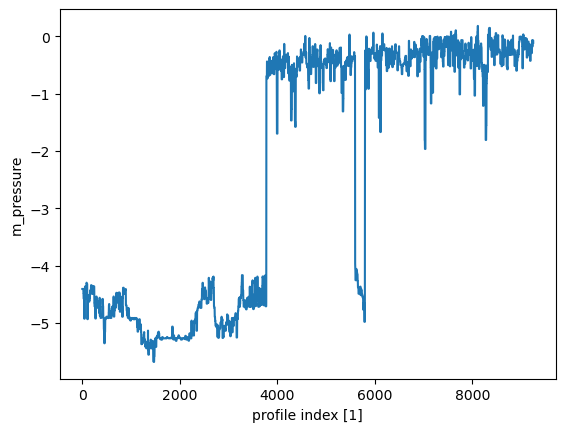

In [ ]:
mbias_.plot()

(np.float64(20398.75), np.float64(20542.958333333332))

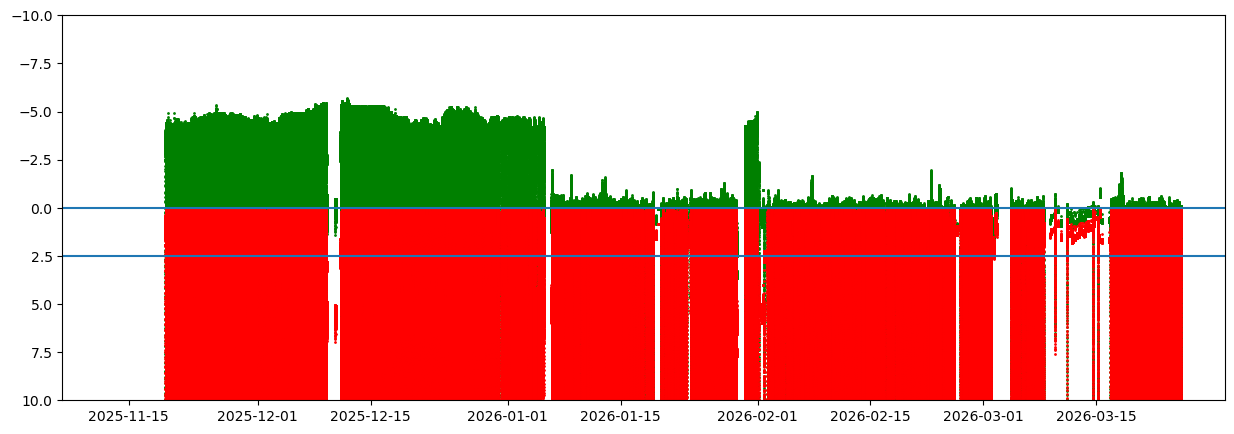

In [70]:
plt.figure(figsize=(15,5))


plt.scatter(ds.time, ds.m_pressure, c='g', s=1,alpha=1)
plt.scatter(ds.time, ds.m_pressure_corr, c='r', s=1,alpha=1)

# plt.scatter(ds.time_ctd, ds.pressure_corr2, c='orange', s=1,alpha=1)

# plt.plot(ds.time, bias_dpth_botd)

# plt.plot(ds.time, bias_dpth_top)
plt.axhline(0)
plt.axhline(2.5)

plt.ylim(10,-10)

plt.xlim(pd.to_datetime('2025-11-06 18:00'), pd.to_datetime('2026-03-30 23:00'))


In [ ]:
# Correct science pressure 
# Compute difference of m_pressure_corr and pressure at top and bottom of dives. Doing dives cause giving a better smothed result!
# Compare bot (pressure_corr) and top differences (pressure_corr2)... seems like using the top works better -- SAVING AS NEW SCI PRESSURE (pressure_corr2)

In [ ]:
# bias_bot=(ds.pressure.groupby(ds.profile_index).max()-(ds.m_pressure_corr).groupby(ds.profile_index).max())
# bias_bot=bias_bot.bfill('profile_index').rolling(profile_index=1,center=True).max()
# bias_dpth_bot=xr.DataArray(bias_bot.sel(profile_index=ds.profile_index).ffill(dim='time').values,dims='time')

bias_botd=(ds.pressure.groupby(ds.dive_index).max()-(ds.m_pressure_corr).groupby(ds.dive_index).max())
bias_botd=bias_botd.bfill('dive_index').rolling(dive_index=3,center=True).median()
bias_dpth_botd=xr.DataArray(bias_botd.sel(dive_index=ds.dive_index).ffill(dim='time').values,dims='time')

# bias_top=(ds.pressure.groupby(ds.profile_index).min()-(ds.m_pressure_corr).groupby(ds.profile_index).min())
# bias_top=bias_top.rolling(profile_index=1,center=True).min()#.bfill('profile_index')
# bias_dpth_top=xr.DataArray(bias_top.sel(profile_index=ds.profile_index).bfill(dim='time').values,dims='time')

bias_topd=(ds.pressure.groupby(ds.dive_index).min()-(ds.m_pressure_corr).groupby(ds.dive_index).min())
bias_topd=bias_topd.rolling(dive_index=3,center=True).min()
bias_dpth_topd=xr.DataArray(bias_topd.sel(dive_index=ds.dive_index).bfill(dim='time').values,dims='time')

ds['pressure_corr']=ds.pressure-bias_dpth_botd
ds['pressure_corr2']=ds.pressure-bias_dpth_topd

(np.float64(20398.75), np.float64(20542.958333333332))

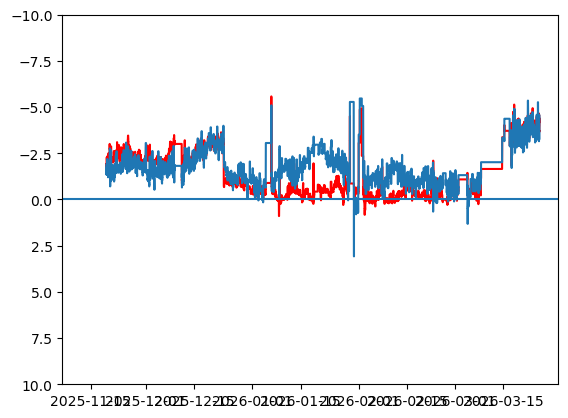

In [83]:
# plt.plot(ds.time, bias_dpth_bot)
plt.plot(ds.time, bias_dpth_botd, c='r')
plt.axhline(0)
plt.plot(ds.time, bias_dpth_topd)
plt.ylim(10,-10)
plt.xlim(pd.to_datetime('2025-11-06 18:00'), pd.to_datetime('2026-03-30 23:00'))


(np.float64(20400.958333333332), np.float64(20542.125))

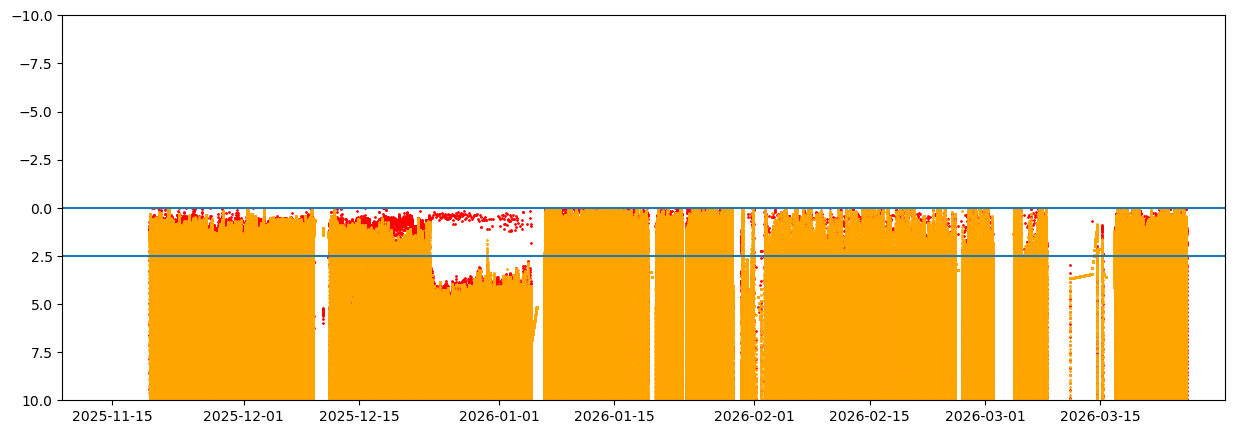

In [86]:
plt.figure(figsize=(15,5))


plt.scatter(ds.time_ctd, ds.m_pressure_corr, c='r', s=1,alpha=1)

# plt.scatter(ds.time_ctd, ds.prssure_corr, c='g', s=1,alpha=1)

plt.scatter(ds.time, ds.pressure_corr2, c='orange', s=1,alpha=1)

# plt.plot(ds.time, bias_dpth_botd)

# plt.plot(ds.time, bias_dpth_top)
plt.axhline(0)
plt.axhline(2.5)

plt.ylim(10,-10)
plt.xlim(pd.to_datetime('2025-11-08 23:00'), pd.to_datetime('2026-03-30 03:00'))
# plt.xlim(pd.to_datetime('2025-12-15 23:00'), pd.to_datetime('2025-12-16 03:00'))
# plt.xlim(pd.to_datetime('2026-01-01 23:00'), pd.to_datetime('2026-01-01 03:00'))
# plt.xlim(pd.to_datetime('2026-02-15 23:00'), pd.to_datetime('2026-02-16 03:00'))


(np.float64(20454.958333333332), np.float64(20454.125))

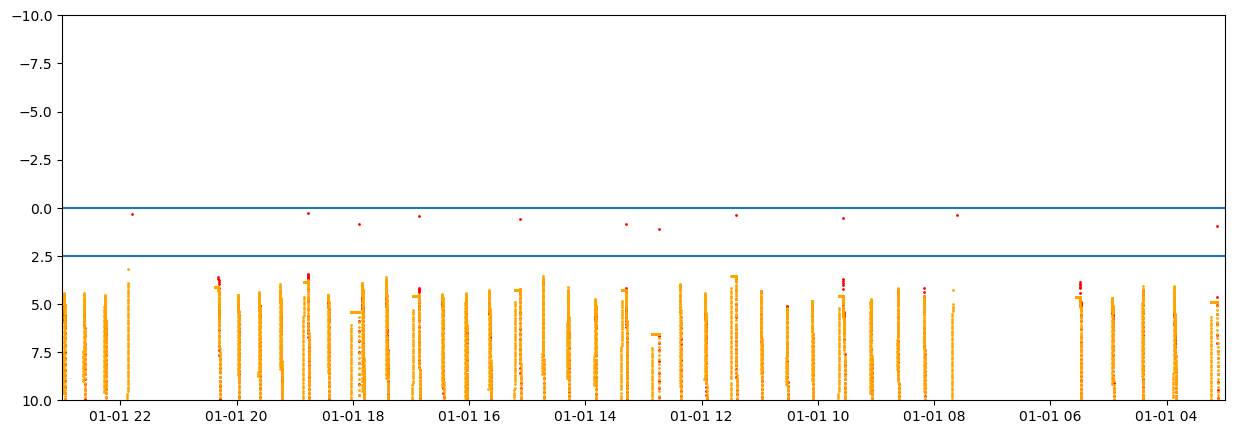

In [87]:
plt.figure(figsize=(15,5))


plt.scatter(ds.time_ctd, ds.m_pressure_corr, c='r', s=1,alpha=1)

# plt.scatter(ds.time_ctd, ds.prssure_corr, c='g', s=1,alpha=1)

plt.scatter(ds.time, ds.pressure_corr2, c='orange', s=1,alpha=1)

# plt.plot(ds.time, bias_dpth_botd)

# plt.plot(ds.time, bias_dpth_top)
plt.axhline(0)
plt.axhline(2.5)

plt.ylim(10,-10)
plt.xlim(pd.to_datetime('2025-11-08 23:00'), pd.to_datetime('2026-03-30 03:00'))
# plt.xlim(pd.to_datetime('2025-12-15 23:00'), pd.to_datetime('2025-12-16 03:00'))
plt.xlim(pd.to_datetime('2026-01-01 23:00'), pd.to_datetime('2026-01-01 03:00'))
# plt.xlim(pd.to_datetime('2026-02-15 23:00'), pd.to_datetime('2026-02-16 03:00'))


(np.float64(20499.958333333332), np.float64(20500.125))

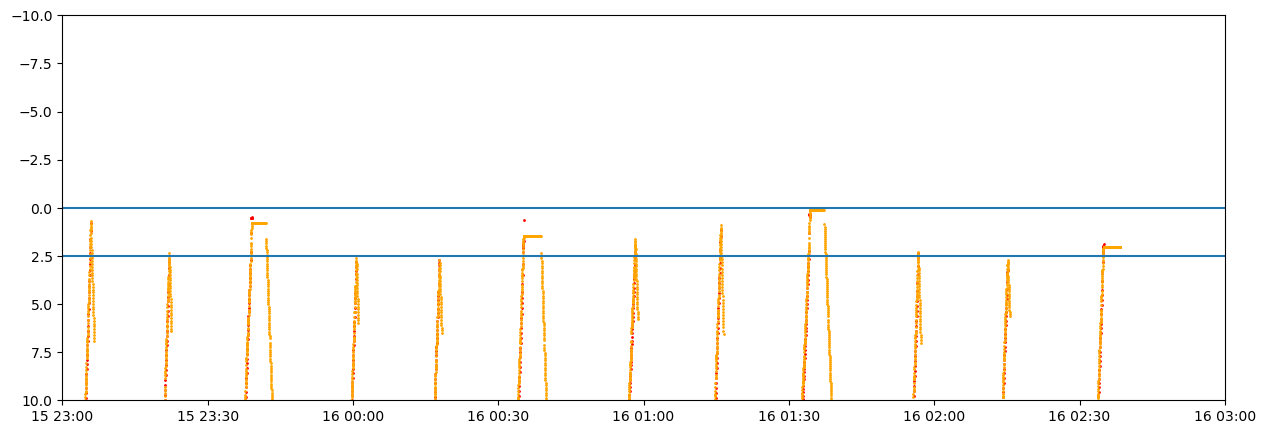

In [88]:
plt.figure(figsize=(15,5))


plt.scatter(ds.time_ctd, ds.m_pressure_corr, c='r', s=1,alpha=1)

# plt.scatter(ds.time_ctd, ds.prssure_corr, c='g', s=1,alpha=1)

plt.scatter(ds.time, ds.pressure_corr2, c='orange', s=1,alpha=1)

# plt.plot(ds.time, bias_dpth_botd)

# plt.plot(ds.time, bias_dpth_top)
plt.axhline(0)
plt.axhline(2.5)

plt.ylim(10,-10)
plt.xlim(pd.to_datetime('2025-11-08 23:00'), pd.to_datetime('2026-03-30 03:00'))
# plt.xlim(pd.to_datetime('2025-12-15 23:00'), pd.to_datetime('2025-12-16 03:00'))
plt.xlim(pd.to_datetime('2026-01-01 23:00'), pd.to_datetime('2026-01-01 03:00'))
plt.xlim(pd.to_datetime('2026-02-15 23:00'), pd.to_datetime('2026-02-16 03:00'))


(np.float64(20400.958333333332), np.float64(20542.125))

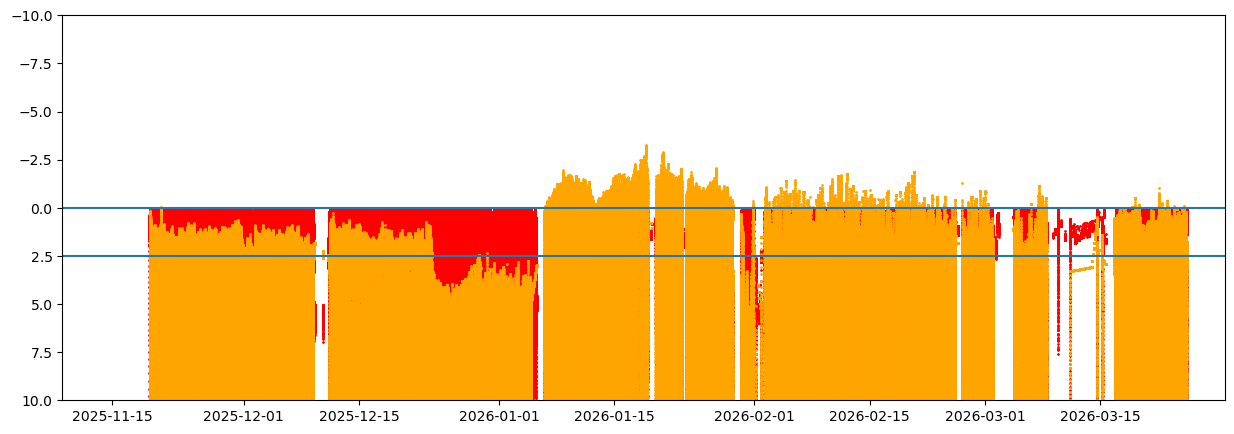

In [77]:
plt.figure(figsize=(15,5))


plt.scatter(ds.time, ds.m_pressure_corr, c='r', s=1,alpha=1)

# plt.scatter(ds.time_ctd, ds.prssure_corr, c='g', s=1,alpha=1)

plt.scatter(ds.time, ds.pressure_corr, c='orange', s=1,alpha=1)

# plt.plot(ds.time, bias_dpth_botd)

# plt.plot(ds.time, bias_dpth_top)
plt.axhline(0)
plt.axhline(2.5)

plt.ylim(10,-10)
plt.xlim(pd.to_datetime('2025-11-08 23:00'), pd.to_datetime('2026-03-30 03:00'))
# plt.xlim(pd.to_datetime('2025-12-15 23:00'), pd.to_datetime('2025-12-16 03:00'))
# plt.xlim(pd.to_datetime('2026-01-01 23:00'), pd.to_datetime('2026-01-01 03:00'))
# plt.xlim(pd.to_datetime('2026-02-15 23:00'), pd.to_datetime('2026-02-16 03:00'))


In [ ]:
## CORRECT LAT AND LON

In [ ]:
def dmm_to_decimal_xr(da):
    """
    Convert degrees & decimal minutes (DMM) in an xarray DataArray
    to decimal degrees.
    Example value: -3219.288051
    """
    sign = xr.where(da < 0, -1, 1)
    abs_da = np.abs(da)

    degrees = (abs_da // 100).astype(int)
    minutes = abs_da - (degrees * 100)

    decimal = degrees + minutes / 60.0
    return sign * decimal

ds['latitude_dmm']=ds.latitude.copy()
ds['longitude_dmm']=ds.longitude.copy()
ds['latitude']=('time', dmm_to_decimal_xr(ds.latitude_dmm.values))
ds['longitude']=('time', dmm_to_decimal_xr(ds.longitude_dmm.values))


In [ ]:
ds=ds.drop_vars('pressure_corr')

/var/folders/69/g5w33vl93q38cbfcgm1pjsbw0000gn/T/ipykernel_4377/1463448949.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds=ds.drop('pressure_corr')


In [99]:
ds['pressure_raw']=ds.pressure.copy()
ds['m_pressure_raw']=ds.m_pressure.copy()
ds['pressure']=ds.pressure_corr2.copy()
ds['m_pressure']=ds.m_pressure_corr.copy()

In [101]:
ds['depth']=gsw.z_from_p(ds.pressure, ds.latitude)

In [103]:
#need thhis to be able to save the nc file..
ts = ds["oxygen_timestamp"]

secs = xr.where(
    ts.notnull(),
    ts.astype("datetime64[s]").astype("int64"),
    np.nan
)

ds["oxygen_timestamp"] = secs
ds["oxygen_timestamp"].attrs.update({
    "long_name": "time measured by oxygen sensor",
    "units": "seconds since 1970-01-01T00:00:00Z"
})


In [107]:
ds.to_netcdf('L0-timeseries/wam_sbus_1230_post_step_1.nc')